[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/07_optimization/notebooks/03_tarea_optimizacion.ipynb)

# Tarea 7: Optimización (20 puntos)

**Entrega:** Lunes 23 de febrero, 2026
**Formato:** Pull request en `estudiantes/<tu-usuario>/tarea_07/` + Canvas

## Instrucciones

Para **cada** problema (5 en total, 4 pts c/u):

| Pts | Qué hacer |
|:---:|-----------|
| 1 | **Formulación matemática** — escribe variables de decisión, función objetivo y restricciones en LaTeX |
| 1 | **Elección de optimizador** — elige el método/solver y explica por qué es adecuado |
| 1 | **Implementación** — completa las funciones esqueleto (las que tienen `raise NotImplementedError`) |
| 1 | **Solución y visualización** — ejecuta, reporta el resultado y visualiza |

**Reglas:**
- Completa SOLO las celdas marcadas con `raise NotImplementedError`
- NO modifiques las celdas de datos
- Escribe la matemática en LaTeX dentro de las celdas markdown indicadas
- Cada función tiene documentación con los inputs/outputs esperados

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import (minimize, minimize_scalar, linprog, milp,
                            LinearConstraint, Bounds,
                            dual_annealing, differential_evolution)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

---
## Problema 1: Nutrición animal (4 puntos)

Un ganadero necesita formular la **dieta diaria** para su ganado. Dispone de 6 ingredientes, cada uno con un costo por kilogramo y un perfil nutricional conocido (energía, proteína, calcio, fósforo).

La dieta debe cumplir **requerimientos mínimos** de cada nutriente, y el **consumo total** debe estar entre 8 y 12 kg por animal. Cada ingrediente tiene un **límite máximo** de inclusión.

El objetivo es **minimizar el costo total** de la dieta diaria por animal.

| Ingrediente | Costo (\$/kg) | Energía (Mcal/kg) | Proteína (g/kg) | Calcio (g/kg) | Fósforo (g/kg) | Max (kg) |
|:-----------:|:------------:|:-----------------:|:---------------:|:------------:|:--------------:|:--------:|
| Maíz        | 4.5          | 3.3               | 90              | 0.3          | 2.8            | 6.0      |
| Soya        | 9.0          | 3.2               | 440             | 2.7          | 6.5            | 3.0      |
| Heno        | 2.5          | 2.0               | 80              | 4.0          | 2.0            | 5.0      |
| Melaza      | 3.0          | 2.8               | 40              | 8.0          | 0.8            | 2.0      |
| Minerales   | 15.0         | 0.0               | 0               | 200.0        | 80.0           | 0.5      |
| Salvado     | 3.5          | 2.5               | 150             | 1.5          | 12.0           | 4.0      |

**Requerimientos mínimos diarios por animal:** Energía >= 25 Mcal, Proteína >= 1000 g, Calcio >= 30 g, Fósforo >= 20 g

**Consumo total:** entre 8 y 12 kg

### 1.1 Formulacion matematica
**Variables de decisión:**
$$ x_i = \text{kg del ingrediente } i \text{ en la dieta diaria}, \quad i = 1, \dots, 6 $$

**Función objetivo:**
$$ \min Z = \sum_{i=1}^{6} c_i \, x_i = \mathbf{c}^\top \mathbf{x} $$

**Restricciones:**
$$\begin{aligned}
& \sum_{i=1}^{6} a_{ji} \, x_i \geq b_j, \quad j = 1, \dots, 4 \quad \text{(requerimientos nutricionales: } \mathbf{A}\mathbf{x} \geq \mathbf{b}\text{)} \\
& 8 \leq \sum_{i=1}^{6} x_i \leq 12 \quad \text{(consumo total)} \\
& 0 \leq x_i \leq \text{max}_i, \quad i = 1, \dots, 6 \quad \text{(cotas por ingrediente)}
\end{aligned}$$


### 1.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:** `scipy.optimize.linprog` con método HiGHS

**Justificacion (2-3 oraciones):**  El problema tiene función objetivo lineal ($\mathbf{c}^\top \mathbf{x}$), restricciones lineales y variables continuas, lo que lo clasifica como un problema de Programación Lineal (LP). HiGHS combina Simplex y punto interior especializados en LP, garantizando el óptimo global con certificado de optimalidad. Alternativas como GD o SLSQP funcionarían (LP $\subset$ convexo), pero no explotan la estructura lineal del problema y carecen de análisis de sensibilidad (precios sombra, costos reducidos).


In [2]:
# === DATOS PROBLEMA 1 (NO MODIFICAR) ===
nombres_p1 = ["Maiz", "Soya", "Heno", "Melaza", "Minerales", "Salvado"]
costos_p1 = np.array([4.5, 9.0, 2.5, 3.0, 15.0, 3.5])

# Contenido nutricional por kg: filas = [energia, proteina, calcio, fosforo]
nutrientes_p1 = np.array([
    [3.3, 3.2, 2.0, 2.8, 0.0, 2.5],   # energia (Mcal/kg)
    [90,  440, 80,  40,  0,   150],     # proteina (g/kg)
    [0.3, 2.7, 4.0, 8.0, 200, 1.5],    # calcio (g/kg)
    [2.8, 6.5, 2.0, 0.8, 80,  12.0],   # fosforo (g/kg)
])
nombres_nutrientes_p1 = ["Energia (Mcal)", "Proteina (g)", "Calcio (g)", "Fosforo (g)"]
req_min_p1 = np.array([25.0, 1000.0, 30.0, 20.0])
max_kg_p1 = np.array([6.0, 3.0, 5.0, 2.0, 0.5, 4.0])
intake_min_p1, intake_max_p1 = 8.0, 12.0

In [3]:
# === IMPLEMENTACION PROBLEMA 1 ===

def objetivo_p1(x):
    """Calcula el costo total de la dieta.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        float -- costo total de la dieta
    """
    return float(costos_p1 @ x)
    # raise NotImplementedError
    



def verificar_p1(x):
    """Verifica si la solucion cumple TODAS las restricciones.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        dict con:
            'factible': bool
            'nutrientes_totales': np.array (4,) -- aporte total de cada nutriente
            'intake_total': float -- kg totales
    """
    # raise NotImplementedError
    nutrientes_totales = nutrientes_p1 @ x          # (4,)
    intake_total = float(np.sum(x))

    factible = (
        np.all(nutrientes_totales >= req_min_p1 - 1e-6)    # nutrientes ≥ mínimos
        and intake_min_p1 - 1e-6 <= intake_total <= intake_max_p1 + 1e-6  # 8 ≤ Σx ≤ 12
        and np.all(x >= -1e-6)                              # no negatividad
        and np.all(x <= max_kg_p1 + 1e-6)                  # cotas superiores
    )

    return {
        'factible': factible,
        'nutrientes_totales': nutrientes_totales,
        'intake_total': intake_total,
    }



def resolver_p1():
    """Resuelve el problema de nutricion animal.

    Usa los datos globales (costos_p1, nutrientes_p1, etc.)
    y el optimizador que elegiste en la seccion 1.2.

    Returns:
        x_opt: np.array (6,) -- kg optimos de cada ingrediente
        costo_opt: float -- costo minimo
    """
    n = len(costos_p1)

    A_ub = np.vstack([
        -nutrientes_p1,                  # (4, 6)
        -np.ones((1, n)),                # (1, 6)
         np.ones((1, n)),                # (1, 6)
    ])

    b_ub = np.concatenate([
        -req_min_p1,                     # (4,)
        [-intake_min_p1],                # (1,)
        [ intake_max_p1],                # (1,)
    ])

    bounds = [(0, max_kg_p1[i]) for i in range(n)]

    result_lp = linprog(
        c=costos_p1,
        A_ub=A_ub,
        b_ub=b_ub,
        bounds=bounds,
        method="highs",
    )

    if not result_lp.success:
        raise ValueError(f"Optimización falló: {result_lp.message}")

    x_opt = result_lp.x
    costo_opt = float(result_lp.fun)

    return x_opt, costo_opt
    # raise NotImplementedError

Solucion P1:
  Maiz: 0.407 kg
  Soya: 0.000 kg
  Heno: 5.000 kg
  Melaza: 2.000 kg
  Minerales: 0.000 kg
  Salvado: 3.222 kg
Costo total: $31.61
Intake total: 10.63 kg
Factible: True


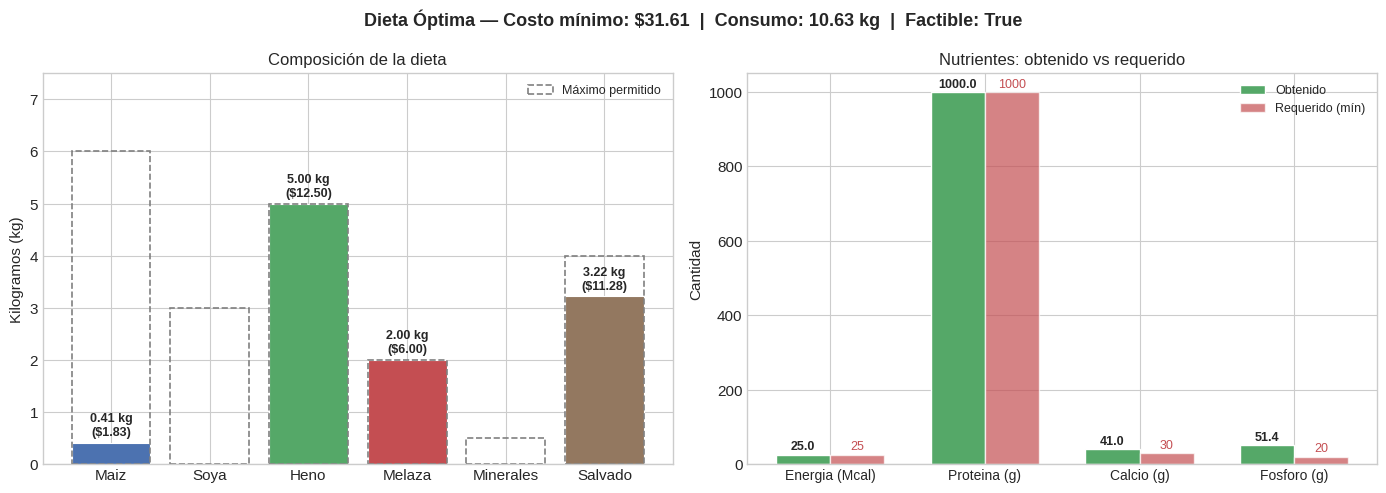

In [4]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 1 ===

def plot_p1(x_opt, costo_opt):
    """Visualiza la solucion del problema de nutricion.

    Debe mostrar:
    - Panel 1: Barras con kg de cada ingrediente
    - Panel 2: Barras comparando nutrientes obtenidos vs requeridos

    Args:
        x_opt: np.array (6,)
        costo_opt: float
    """
    # raise NotImplementedError
    info = verificar_p1(x_opt)
    nutrientes_totales = info['nutrientes_totales']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Dieta Óptima — Costo mínimo: ${costo_opt:.2f}  |  "
                 f"Consumo: {info['intake_total']:.2f} kg  |  "
                 f"Factible: {info['factible']}",
                 fontsize=13, fontweight='bold')

    # ── Panel 1: kg por ingrediente ──────────────────────────────────
    colores_ing = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
    bars1 = ax1.bar(nombres_p1, x_opt, color=colores_ing, edgecolor='white', linewidth=0.8)

    # Etiquetas con kg y costo sobre cada barra
    for bar, xi, ci in zip(bars1, x_opt, costos_p1):
        if xi > 1e-6:
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08,
                     f'{xi:.2f} kg\n(${ci * xi:.2f})',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Línea de cota superior
    ax1.bar(nombres_p1, max_kg_p1, fill=False, edgecolor='gray',
            linestyle='--', linewidth=1.2, label='Máximo permitido')

    ax1.set_ylabel('Kilogramos (kg)', fontsize=11)
    ax1.set_title('Composición de la dieta', fontsize=12)
    ax1.legend(fontsize=9)
    ax1.set_ylim(0, max(max_kg_p1) * 1.25)

    # ── Panel 2: nutrientes obtenidos vs requeridos ──────────────────
    x_pos = np.arange(len(nombres_nutrientes_p1))
    ancho = 0.35

    bars_obt = ax2.bar(x_pos - ancho/2, nutrientes_totales, ancho,
                       label='Obtenido', color='#55A868', edgecolor='white')
    bars_req = ax2.bar(x_pos + ancho/2, req_min_p1, ancho,
                       label='Requerido (mín)', color='#C44E52', alpha=0.7, edgecolor='white')

    # Etiquetas con valor sobre cada barra
    for bar, val in zip(bars_obt, nutrientes_totales):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar, val in zip(bars_req, req_min_p1):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=9, color='#C44E52')

    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(nombres_nutrientes_p1, fontsize=10)
    ax2.set_ylabel('Cantidad', fontsize=11)
    ax2.set_title('Nutrientes: obtenido vs requerido', fontsize=12)
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


# Resolver y visualizar
x_opt_p1, costo_opt_p1 = resolver_p1()
info_p1 = verificar_p1(x_opt_p1)

print(f"Solucion P1:")
for nombre, kg in zip(nombres_p1, x_opt_p1):
    print(f"  {nombre}: {kg:.3f} kg")
print(f"Costo total: ${costo_opt_p1:.2f}")
print(f"Intake total: {info_p1['intake_total']:.2f} kg")
print(f"Factible: {info_p1['factible']}")

plot_p1(x_opt_p1, costo_opt_p1)

---
## Problema 2: Portafolio de inversion (4 puntos)

Un inversionista tiene capital para distribuir entre 5 activos financieros. Cada activo tiene un **rendimiento esperado** y una **covarianza** conocida con los demas activos (ver datos).

El objetivo es **minimizar el riesgo** del portafolio (medido como la varianza del rendimiento), sujeto a:
- El rendimiento esperado del portafolio debe ser **al menos 8%**
- Todo el capital debe invertirse (las proporciones suman 1)
- No se permiten ventas en corto (todas las proporciones >= 0)
- Ningun activo puede representar mas del **40%** del portafolio

### 2.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decisión:**
$$ w_i = \text{proporción del capital invertida en el activo } i, \quad i = 1, \dots, 5 $$

**Función objetivo:**
$$ \min \sigma_p^2 = \sum_{i=1}^{5} \sum_{j=1}^{5} w_i \, \Sigma_{ij} \, w_j = \mathbf{w}^\top \boldsymbol{\Sigma} \, \mathbf{w} $$

**Restricciones:**
$$\begin{aligned}
& \sum_{i=1}^{5} \mu_i \, w_i \geq 0.08 \quad \text{(rendimiento mínimo: } \boldsymbol{\mu}^\top \mathbf{w} \geq 0.08\text{)} \\
& \sum_{i=1}^{5} w_i = 1 \quad \text{(todo el capital invertido)} \\
& 0 \leq w_i \leq 0.40, \quad i = 1, \dots, 5 \quad \text{(sin ventas en corto + diversificación)}
\end{aligned}$$

### 2.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**`scipy.optimize.minimize` con método SLSQP

**Justificacion (2-3 oraciones):**La función objetivo es cuadrática ($\mathbf{w}^\top \boldsymbol{\Sigma} \, \mathbf{w}$) con $\boldsymbol{\Sigma} \succeq 0$, y las restricciones incluyen tanto igualdades ($\sum w_i = 1$) como desigualdades lineales, lo que lo clasifica como un problema QP convexo. SLSQP implementa Programación Cuadrática Secuencial, que resuelve subproblemas QP aplicando condiciones KKT, garantizando convergencia al óptimo global en problemas convexos. GD/SGD no son adecuados porque no manejan restricciones de igualdad directamente y requerirían proyecciones o penalizaciones innecesarias.

In [5]:
# === DATOS PROBLEMA 2 (NO MODIFICAR) ===
activos_p2 = ["Bonos gob.", "Acciones tech", "Bienes raices", "Materias primas", "Mercados emergentes"]
rendimientos_p2 = np.array([0.03, 0.14, 0.08, 0.11, 0.16])

cov_p2 = np.array([
    [0.0004, 0.0002, 0.0001, 0.0000, 0.0003],
    [0.0002, 0.0100, 0.0030, 0.0050, 0.0080],
    [0.0001, 0.0030, 0.0025, 0.0015, 0.0020],
    [0.0000, 0.0050, 0.0015, 0.0064, 0.0040],
    [0.0003, 0.0080, 0.0020, 0.0040, 0.0144],
])

retorno_minimo_p2 = 0.08
max_por_activo_p2 = 0.40

In [6]:
# === IMPLEMENTACION PROBLEMA 2 ===

def objetivo_p2(w):
    """Calcula la varianza (riesgo) del portafolio.

    Args:
        w: np.array (5,) -- proporcion invertida en cada activo

    Returns:
        float -- varianza del portafolio
    """
    # raise NotImplementedError
    return float(w @ cov_p2 @ w)


def verificar_p2(w):
    """Verifica si el portafolio cumple todas las restricciones.

    Args:
        w: np.array (5,) -- proporciones

    Returns:
        dict con:
            'factible': bool
            'rendimiento': float -- rendimiento esperado del portafolio
            'varianza': float
            'suma_pesos': float
    """
    # raise NotImplementedError
    rendimiento = float(rendimientos_p2 @ w)
    varianza = objetivo_p2(w)
    suma_pesos = float(np.sum(w))

    factible = (
        rendimiento >= retorno_minimo_p2 - 1e-6          # μ^T w ≥ 0.08
        and abs(suma_pesos - 1.0) < 1e-6                 # 1^T w = 1
        and np.all(w >= -1e-6)                            # w_i ≥ 0
        and np.all(w <= max_por_activo_p2 + 1e-6)        # w_i ≤ 0.40
    )

    return {
        'factible': factible,
        'rendimiento': rendimiento,
        'varianza': varianza,
        'suma_pesos': suma_pesos,
    }


def resolver_p2():
    """Resuelve el problema de portafolio.

    Returns:
        w_opt: np.array (5,) -- proporciones optimas
        varianza_opt: float -- varianza minima
    """
    # raise NotImplementedError
    n = len(rendimientos_p2)

    w0 = np.ones(n) / n

    constraints = [
        {"type": "eq",   "fun": lambda w: np.sum(w) - 1.0},
        {"type": "ineq", "fun": lambda w: rendimientos_p2 @ w - retorno_minimo_p2},
    ]

    bounds = [(0, max_por_activo_p2) for _ in range(n)]

    result = minimize(
        fun=objetivo_p2,
        x0=w0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
    )

    if not result.success:
        raise ValueError(f"Optimización falló: {result.message}")

    w_opt = result.x
    varianza_opt = float(result.fun)

    return w_opt, varianza_opt


Solucion P2:
  Bonos gob.: 35.7%
  Acciones tech: 9.9%
  Bienes raices: 27.4%
  Materias primas: 19.4%
  Mercados emergentes: 7.6%
Rendimiento esperado: 8.00%
Varianza: 0.001548
Desv. estandar: 3.93%
Factible: True


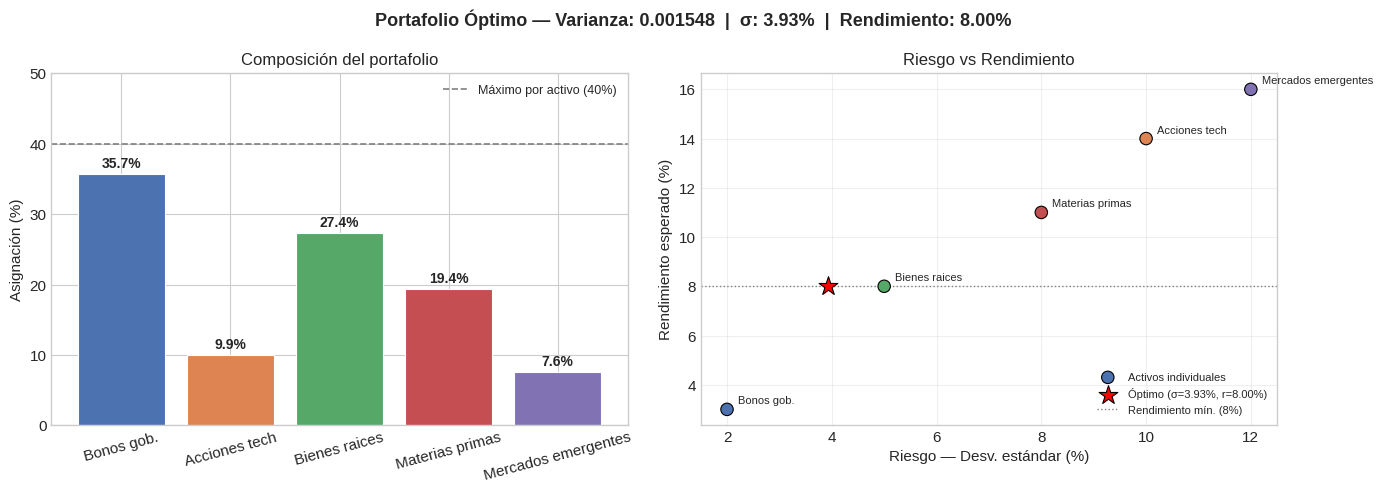

In [7]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 2 ===

def plot_p2(w_opt, varianza_opt):
    """Visualiza la solucion del portafolio.

    Debe mostrar:
    - Panel 1: Barras con la asignacion del portafolio (% por activo)
    - Panel 2: Rendimiento vs riesgo del portafolio optimo

    Args:
        w_opt: np.array (5,)
        varianza_opt: float
    """
    info = verificar_p2(w_opt)
    sigma_opt = np.sqrt(varianza_opt)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Portafolio Óptimo — Varianza: {varianza_opt:.6f}  |  "
                 f"σ: {sigma_opt*100:.2f}%  |  "
                 f"Rendimiento: {info['rendimiento']*100:.2f}%",
                 fontsize=13, fontweight='bold')

    # ── Panel 1: Barras con % por activo ─────────────────────────────
    colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
    bars = ax1.bar(activos_p2, w_opt * 100, color=colores, edgecolor='white', linewidth=0.8)

    for bar, wi in zip(bars, w_opt):
        if wi > 1e-6:
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                     f'{wi*100:.1f}%', ha='center', va='bottom',
                     fontsize=10, fontweight='bold')

    ax1.axhline(y=max_por_activo_p2 * 100, color='gray', linestyle='--',
                linewidth=1.2, label=f'Máximo por activo ({max_por_activo_p2*100:.0f}%)')

    ax1.set_ylabel('Asignación (%)', fontsize=11)
    ax1.set_title('Composición del portafolio', fontsize=12)
    ax1.set_ylim(0, 50)
    ax1.legend(fontsize=9)
    ax1.tick_params(axis='x', rotation=15)

    # ── Panel 2: Rendimiento vs Riesgo ───────────────────────────────
    sigmas_ind = np.sqrt(np.diag(cov_p2))

    # Activos individuales
    ax2.scatter(sigmas_ind * 100, rendimientos_p2 * 100, s=80,
                color=colores, edgecolors='black', linewidth=0.8,
                zorder=3, label='Activos individuales')
    for i, act in enumerate(activos_p2):
        ax2.annotate(act, (sigmas_ind[i]*100, rendimientos_p2[i]*100),
                     textcoords="offset points", xytext=(8, 4), fontsize=8)

    # Portafolio óptimo
    ax2.scatter(sigma_opt * 100, info['rendimiento'] * 100, s=200,
                color='red', marker='*', edgecolors='black', linewidth=0.8,
                zorder=4, label=f'Óptimo (σ={sigma_opt*100:.2f}%, r={info["rendimiento"]*100:.2f}%)')

    # Línea de rendimiento mínimo
    ax2.axhline(y=retorno_minimo_p2 * 100, color='gray', linestyle=':',
                linewidth=1, label=f'Rendimiento mín. ({retorno_minimo_p2*100:.0f}%)')

    ax2.set_xlabel('Riesgo — Desv. estándar (%)', fontsize=11)
    ax2.set_ylabel('Rendimiento esperado (%)', fontsize=11)
    ax2.set_title('Riesgo vs Rendimiento', fontsize=12)
    ax2.legend(fontsize=8, loc='lower right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


    # raise NotImplementedError


w_opt_p2, var_opt_p2 = resolver_p2()
info_p2 = verificar_p2(w_opt_p2)

print(f"Solucion P2:")
for activo, w in zip(activos_p2, w_opt_p2):
    print(f"  {activo}: {w*100:.1f}%")
print(f"Rendimiento esperado: {info_p2['rendimiento']*100:.2f}%")
print(f"Varianza: {var_opt_p2:.6f}")
print(f"Desv. estandar: {np.sqrt(var_opt_p2)*100:.2f}%")
print(f"Factible: {info_p2['factible']}")

plot_p2(w_opt_p2, var_opt_p2)

---
## Problema 3: Cobertura con antenas (4 puntos)

Una empresa de telecomunicaciones necesita dar cobertura de senal en **10 zonas** de una ciudad. Existen **7 ubicaciones** posibles para instalar torres de transmision. Cada torre tiene un costo de construccion y cubre un conjunto especifico de zonas (ver tabla).

El objetivo es **seleccionar que torres construir** para cubrir **todas las zonas** al **minimo costo** total. Cada torre se construye completamente o no se construye (decision binaria).

| Torre | Costo (miles \$) | Zonas que cubre |
|:-----:|:----------------:|:---------------:|
| T1    | 50               | 1, 2, 3         |
| T2    | 80               | 2, 3, 4, 5      |
| T3    | 60               | 4, 5, 6         |
| T4    | 70               | 5, 6, 7, 8      |
| T5    | 90               | 7, 8, 9, 10     |
| T6    | 40               | 1, 9, 10        |
| T7    | 75               | 3, 6, 7         |

### 3.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**
$$ y_i \in \{0, 1\}, \quad i = 1, \dots, 7 \quad \text{(1 si se construye la torre } i\text{, 0 si no)} $$

**Funcion objetivo:**
$$ \min Z = \sum_{i=1}^{7} c_i \, y_i = \mathbf{c}^\top \mathbf{y} $$

**Restricciones:**

$$\begin{aligned}
& \sum_{i : j \in S_i} y_i \geq 1, \quad \forall \, j = 1, \dots, 10 \quad \text{(toda zona cubierta por al menos una torre: } \mathbf{A}^\top \mathbf{y} \geq \mathbf{1}\text{)} \\
& y_i \in \{0, 1\}, \quad i = 1, \dots, 7 \quad \text{(decisión binaria)}
\end{aligned}$$

### 3.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**
`scipy.optimize.milp` con Branch-and-Bound

**Justificacion (2-3 oraciones):**
El problema tiene función objetivo lineal y restricciones lineales, pero las variables son binarias ($y_i \in \{0,1\}$), lo que lo clasifica como un problema de Programación Lineal Entera Mixta (MILP), específicamente un Set Covering Problem. `milp` utiliza Branch-and-Bound para explorar el espacio de soluciones enteras, garantizando el óptimo entero. Solvers continuos como `linprog` o `SLSQP` no pueden manejar la restricción de integralidad.


In [8]:
# === DATOS PROBLEMA 3 (NO MODIFICAR) ===
n_torres_p3 = 7
n_zonas_p3 = 10
costos_torres_p3 = np.array([50, 80, 60, 70, 90, 40, 75])
nombres_torres_p3 = [f"T{i+1}" for i in range(n_torres_p3)]

# cobertura_p3[i, j] = 1 si torre i cubre zona j+1
cobertura_p3 = np.array([
    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0],  # T1: zonas 1,2,3
    [0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # T2: zonas 2,3,4,5
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],  # T3: zonas 4,5,6
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],  # T4: zonas 5,6,7,8
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],  # T5: zonas 7,8,9,10
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 1],  # T6: zonas 1,9,10
    [0, 0, 1, 0, 0, 1, 1, 0, 0, 0],  # T7: zonas 3,6,7
])

In [11]:
# === IMPLEMENTACION PROBLEMA 3 ===

def objetivo_p3(y):
    """Calcula el costo total de las torres seleccionadas.

    Args:
        y: np.array (7,) -- 1 si se construye la torre, 0 si no

    Returns:
        float -- costo total
    """
    # raise NotImplementedError
    return float(costos_torres_p3 @ y)


def verificar_p3(y):
    """Verifica si la seleccion de torres cubre TODAS las zonas.

    Args:
        y: np.array (7,) -- seleccion de torres

    Returns:
        dict con:
            'factible': bool -- True si todas las zonas estan cubiertas
            'zonas_cubiertas': list -- indices de zonas cubiertas
            'zonas_sin_cubrir': list -- indices de zonas sin cobertura
    """
    # raise NotImplementedError
    cobertura_total = cobertura_p3.T @ y  # (10,)

    zonas_cubiertas = [j + 1 for j in range(n_zonas_p3) if cobertura_total[j] >= 1 - 1e-6]
    zonas_sin_cubrir = [j + 1 for j in range(n_zonas_p3) if cobertura_total[j] < 1 - 1e-6]

    factible = len(zonas_sin_cubrir) == 0

    return {
        'factible': factible,
        'zonas_cubiertas': zonas_cubiertas,
        'zonas_sin_cubrir': zonas_sin_cubrir,
    }


def resolver_p3():
    """Resuelve el problema de cobertura con antenas.

    Returns:
        y_opt: np.array (7,) -- seleccion optima de torres
        costo_opt: float -- costo minimo
    """
    # raise NotImplementedError
    constraints = LinearConstraint(
        A=cobertura_p3.T,                          # (10, 7)
        lb=np.ones(n_zonas_p3),                    # ≥ 1 para cada zona
        ub=np.full(n_zonas_p3, np.inf),            # sin cota superior
    )

    # Cotas: y_i ∈ {0, 1} → 0 ≤ y_i ≤ 1 + integralidad
    bounds = Bounds(lb=0, ub=1)

    # Integralidad: 1 = variable entera (binaria dado bounds 0-1)
    integrality = np.ones(n_torres_p3)

    result = milp(
        c=costos_torres_p3,
        constraints=constraints,
        bounds=bounds,
        integrality=integrality,
    )

    if not result.success:
        raise ValueError(f"Optimización falló: {result.message}")

    y_opt = np.round(result.x).astype(int)
    costo_opt = float(result.fun)

    return y_opt, costo_opt


Solucion P3:
  T2: Construir (costo=$80k, cubre zonas [2, 3, 4, 5])
  T4: Construir (costo=$70k, cubre zonas [5, 6, 7, 8])
  T6: Construir (costo=$40k, cubre zonas [1, 9, 10])
Costo total: $190k
Factible: True
Zonas sin cubrir: []


/tmp/ipykernel_21059/3585827330.py:71: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21059/3585827330.py:71: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/saulrojas/ia_p26/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saulrojas/ia_p26/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


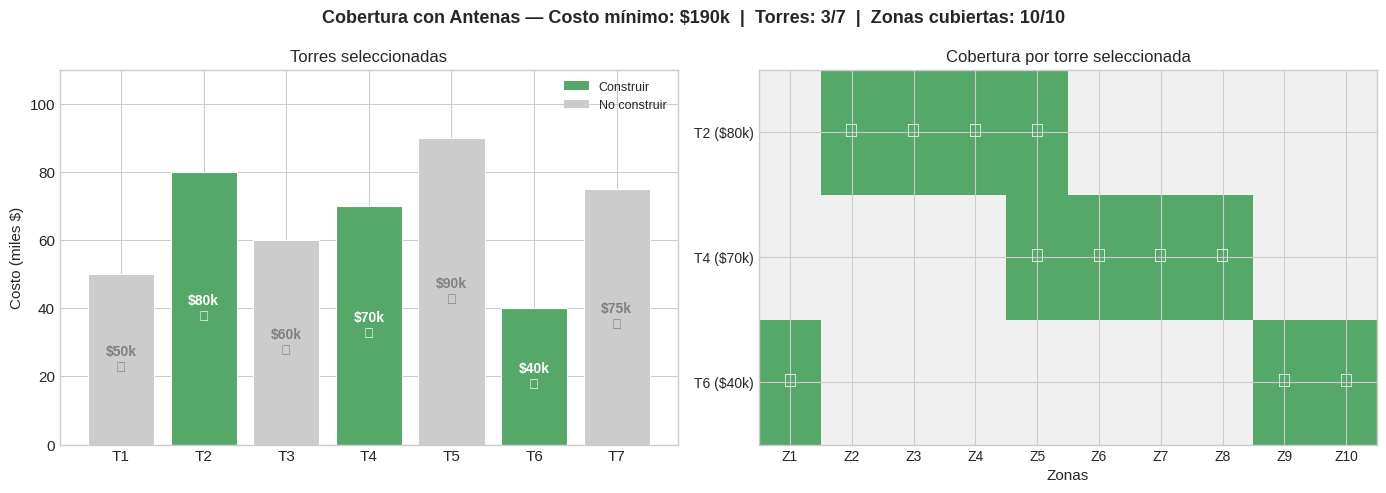

In [12]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 3 ===

def plot_p3(y_opt, costo_opt):
    """Visualiza la seleccion de torres y la cobertura.

    Debe mostrar:
    - Que torres se seleccionaron (con costos)
    - Que zonas cubre cada torre seleccionada

    Args:
        y_opt: np.array (7,)
        costo_opt: float
    """
    # raise NotImplementedError
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Cobertura con Antenas — Costo mínimo: ${costo_opt:.0f}k  |  "
                 f"Torres: {int(y_opt.sum())}/{n_torres_p3}  |  "
                 f"Zonas cubiertas: {n_zonas_p3}/{n_zonas_p3}",
                 fontsize=13, fontweight='bold')

    # ── Panel 1: Torres seleccionadas con costos ─────────────────────
    colores_torre = ['#55A868' if yi else '#CCCCCC' for yi in y_opt]
    bars = ax1.bar(nombres_torres_p3, costos_torres_p3, color=colores_torre,
                   edgecolor='white', linewidth=0.8)

    for bar, yi, ci in zip(bars, y_opt, costos_torres_p3):
        etiqueta = f'${ci}k\n✓' if yi else f'${ci}k\n✗'
        color_txt = 'white' if yi else 'gray'
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
                 etiqueta, ha='center', va='center',
                 fontsize=10, fontweight='bold', color=color_txt)

    # Leyenda manual
    from matplotlib.patches import Patch
    ax1.legend(handles=[
        Patch(facecolor='#55A868', label='Construir'),
        Patch(facecolor='#CCCCCC', label='No construir'),
    ], fontsize=9)

    ax1.set_ylabel('Costo (miles $)', fontsize=11)
    ax1.set_title('Torres seleccionadas', fontsize=12)
    ax1.set_ylim(0, 110)

    # ── Panel 2: Matriz de cobertura (torres seleccionadas × zonas) ──
    torres_sel = [i for i in range(n_torres_p3) if y_opt[i]]
    zonas = [f'Z{j+1}' for j in range(n_zonas_p3)]
    torres_sel_nombres = [nombres_torres_p3[i] for i in torres_sel]

    # Submatriz de cobertura solo con torres seleccionadas
    sub_cobertura = cobertura_p3[torres_sel, :]  # (n_sel, 10)

    # Colores: verde si cubre, blanco si no
    cmap = plt.cm.colors.ListedColormap(['#F0F0F0', '#55A868'])
    ax2.imshow(sub_cobertura, cmap=cmap, aspect='auto', vmin=0, vmax=1)

    # Etiquetas en cada celda
    for i in range(len(torres_sel)):
        for j in range(n_zonas_p3):
            if sub_cobertura[i, j]:
                ax2.text(j, i, '✓', ha='center', va='center',
                         fontsize=14, fontweight='bold', color='white')

    ax2.set_xticks(range(n_zonas_p3))
    ax2.set_xticklabels(zonas, fontsize=10)
    ax2.set_yticks(range(len(torres_sel)))
    ax2.set_yticklabels([f'{t} (${costos_torres_p3[i]}k)' for t, i
                         in zip(torres_sel_nombres, torres_sel)], fontsize=10)
    ax2.set_xlabel('Zonas', fontsize=11)
    ax2.set_title('Cobertura por torre seleccionada', fontsize=12)

    plt.tight_layout()
    plt.show()


y_opt_p3, costo_opt_p3 = resolver_p3()
info_p3 = verificar_p3(y_opt_p3)

print(f"Solucion P3:")
for i, (nombre, sel) in enumerate(zip(nombres_torres_p3, y_opt_p3)):
    if sel > 0.5:
        zonas = [j+1 for j in range(n_zonas_p3) if cobertura_p3[i, j] == 1]
        print(f"  {nombre}: Construir (costo=${costos_torres_p3[i]:.0f}k, cubre zonas {zonas})")
print(f"Costo total: ${costo_opt_p3:.0f}k")
print(f"Factible: {info_p3['factible']}")
print(f"Zonas sin cubrir: {info_p3['zonas_sin_cubrir']}")

plot_p3(y_opt_p3, costo_opt_p3)

---
## Problema 4: Calibracion de sensor (4 puntos)

Un ingeniero necesita calibrar un sensor cuya respuesta sigue el modelo:

$$y(t) = a \cdot \sin(b \cdot t + c) + d \cdot e^{-0.1 \cdot t}$$

donde $a, b, c, d$ son parametros desconocidos y $t$ es la posicion del sensor.

Se tienen **20 mediciones** del sensor en posiciones conocidas (ver datos). El objetivo es encontrar los parametros $a, b, c, d$ que **minimicen el error** entre las predicciones del modelo y las mediciones observadas.

**Nota:** El paisaje de error tiene **multiples minimos locales** debido a los terminos trigonometricos.

**Cotas de los parametros:** $a \in [0, 5]$, $b \in [0, 10]$, $c \in [0, 2\pi]$, $d \in [-3, 3]$

### 4.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

$$ \boldsymbol{\theta} = (a, b, c, d) \quad \text{(parámetros del modelo del sensor)} $$


**Funcion objetivo:**
$$ \min_{\boldsymbol{\theta}} \frac{1}{20} \sum_{i=1}^{20} \left( y_{\text{obs},i} - \left[ a \sin(b \, t_i + c) + d \, e^{-0.1 \, t_i} \right] \right)^2 $$

**Restricciones:**

$$\begin{aligned}
& 0 \leq a \leq 5 \\
& 0 \leq b \leq 10 \\
& 0 \leq c \leq 2\pi \\
& -3 \leq d \leq 3
\end{aligned}$$

### 4.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**

`scipy.optimize.differential_evolution` con `polish=True`


**Justificacion (2-3 oraciones):**

La función objetivo es no lineal y no convexa (contiene $\sin$ y $\exp$), con múltiples mínimos locales debido al término trigonométrico, y el dominio es acotado (box constraints). `differential_evolution` es un algoritmo evolutivo que explora globalmente el espacio acotado sin requerir gradientes, evitando quedar atrapado en mínimos locales. El parámetro `polish=True` refina la mejor solución encontrada con L-BFGS-B para máxima precisión local.


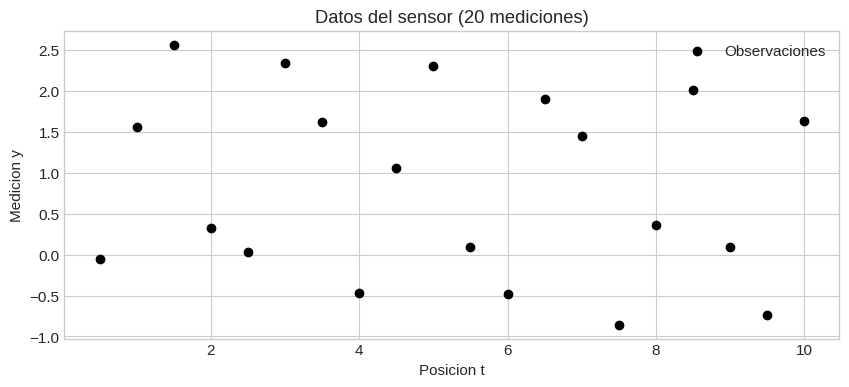

In [13]:
# === DATOS PROBLEMA 4 (NO MODIFICAR) ===

def modelo_sensor(t, params):
    """Modelo del sensor: y = a*sin(b*t + c) + d*exp(-0.1*t)

    Args:
        t: np.array -- posiciones
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        np.array -- predicciones del modelo
    """
    a, b, c, d = params
    return a * np.sin(b * t + c) + d * np.exp(-0.1 * t)

# Posiciones de medicion
t_obs_p4 = np.linspace(0.5, 10.0, 20)

# Mediciones observadas (generadas con parametros ocultos + ruido)
_rng_p4 = np.random.default_rng(2026)
_params_ocultos = _rng_p4.uniform([1, 1, 0, 0.5], [4, 5, 2*np.pi, 3])
y_obs_p4 = modelo_sensor(t_obs_p4, _params_ocultos) + _rng_p4.normal(0, 0.2, 20)
del _rng_p4, _params_ocultos

bounds_p4 = [(0, 5), (0, 10), (0, 2*np.pi), (-3, 3)]

# Visualizar los datos
plt.figure(figsize=(10, 4))
plt.scatter(t_obs_p4, y_obs_p4, color="black", zorder=5, label="Observaciones")
plt.xlabel("Posicion t"); plt.ylabel("Medicion y")
plt.title("Datos del sensor (20 mediciones)")
plt.legend(); plt.show()

In [14]:
# === IMPLEMENTACION PROBLEMA 4 ===

def objetivo_p4(params):
    """Calcula el error entre el modelo y las observaciones.

    Args:
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        float -- error total (escalar)
    """
    # raise NotImplementedError
    y_pred = modelo_sensor(t_obs_p4, params)
    return float(np.mean((y_obs_p4 - y_pred) ** 2))


def resolver_p4():
    """Resuelve el problema de calibracion.

    Returns:
        params_opt: np.array (4,) -- parametros optimos [a, b, c, d]
        error_opt: float -- error minimo encontrado
    """
    # raise NotImplementedError
    result = differential_evolution(
        func=objetivo_p4,
        bounds=bounds_p4,
        seed=42,
        tol=1e-12,
        maxiter=1000,
        polish=True,  # refina con L-BFGS-B al final
    )

    if not result.success:
        raise ValueError(f"Optimización falló: {result.message}")

    params_opt = result.x
    error_opt = float(result.fun)

    return params_opt, error_opt

Solucion P4:
  a = 1.5090
  b = 3.5530
  c = 2.9058
  d = 1.4254
Error: 0.004419


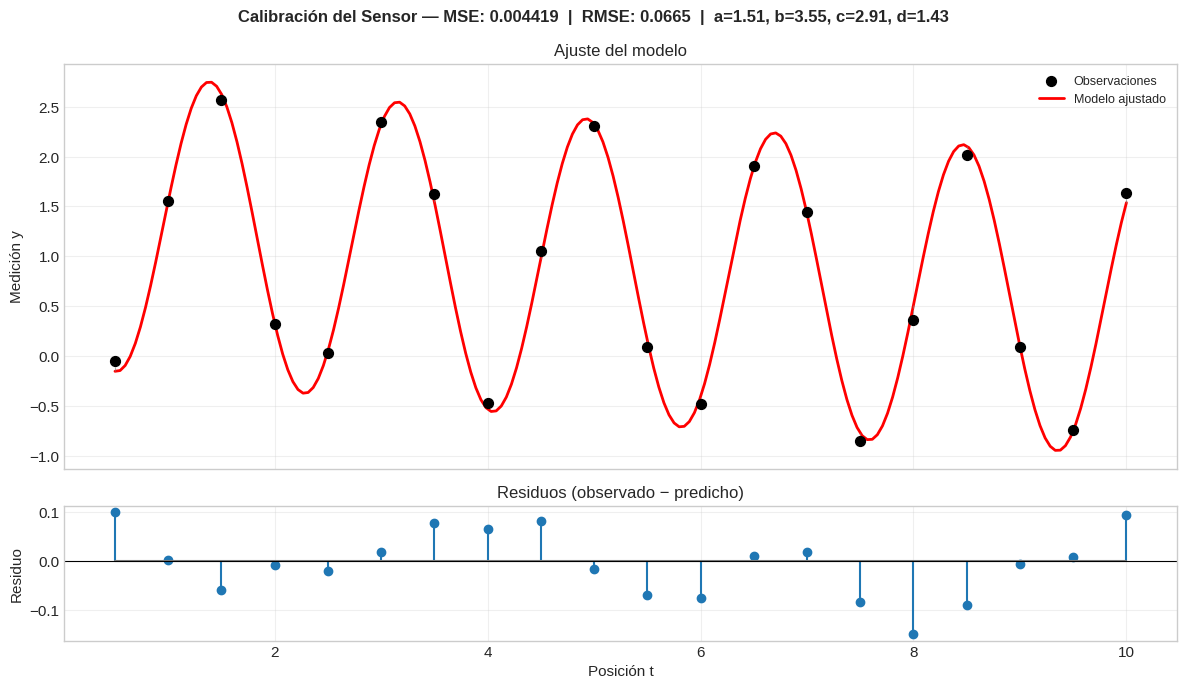

In [16]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 4 ===

def plot_p4(params_opt, error_opt):
    """Visualiza el ajuste del modelo a los datos.

    Debe mostrar:
    - Datos observados (puntos)
    - Curva del modelo con parametros encontrados (linea)
    - Residuos (errores punto a punto)

    Args:
        params_opt: np.array (4,)
        error_opt: float
    """
    # raise NotImplementedError
    y_pred = modelo_sensor(t_obs_p4, params_opt)
    residuos = y_obs_p4 - y_pred
    t_fine = np.linspace(0.5, 10.0, 200)
    y_fine = modelo_sensor(t_fine, params_opt)

    a, b, c, d = params_opt
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), height_ratios=[3, 1],
                                    sharex=True)
    fig.suptitle(f"Calibración del Sensor — MSE: {error_opt:.6f}  |  "
                 f"RMSE: {np.sqrt(error_opt):.4f}  |  "
                 f"a={a:.2f}, b={b:.2f}, c={c:.2f}, d={d:.2f}",
                 fontsize=12, fontweight='bold')

    # ── Panel 1: Datos observados + curva ajustada ───────────────────
    ax1.scatter(t_obs_p4, y_obs_p4, color='black', s=50, zorder=5,
                label='Observaciones')
    ax1.plot(t_fine, y_fine, 'r-', linewidth=2, label='Modelo ajustado')

    # Líneas verticales del residuo (conectan observación con curva)
    for ti, yo, yp in zip(t_obs_p4, y_obs_p4, y_pred):
        ax1.plot([ti, ti], [yo, yp], color='gray', linewidth=0.8,
                 linestyle='--', alpha=0.6)

    ax1.set_ylabel('Medición y', fontsize=11)
    ax1.set_title('Ajuste del modelo', fontsize=12)
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # ── Panel 2: Residuos ────────────────────────────────────────────
    ax2.stem(t_obs_p4, residuos, linefmt='C0-', markerfmt='C0o', basefmt='gray')
    ax2.axhline(y=0, color='black', linewidth=0.8)
    ax2.set_xlabel('Posición t', fontsize=11)
    ax2.set_ylabel('Residuo', fontsize=11)
    ax2.set_title('Residuos (observado − predicho)', fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


params_opt_p4, error_opt_p4 = resolver_p4()

print(f"Solucion P4:")
print(f"  a = {params_opt_p4[0]:.4f}")
print(f"  b = {params_opt_p4[1]:.4f}")
print(f"  c = {params_opt_p4[2]:.4f}")
print(f"  d = {params_opt_p4[3]:.4f}")
print(f"Error: {error_opt_p4:.6f}")

plot_p4(params_opt_p4, error_opt_p4)

---
## Problema 5: Red de distribucion (4 puntos)

Una empresa de logistica considera abrir centros de distribucion (CDs) en **4 ciudades** posibles para atender a **6 clientes**. Cada CD tiene un **costo fijo** de apertura, una **capacidad maxima**, y un **costo de envio por unidad** a cada cliente. Cada cliente tiene una **demanda** que debe ser satisfecha completamente.

La empresa debe decidir:
1. **Que CDs abrir** (decision binaria: abrir o no)
2. **Cuantas unidades enviar** de cada CD abierto a cada cliente (decision continua)

El objetivo es **minimizar el costo total** (costos fijos de apertura + costos de envio).

| CD | Ciudad      | Costo fijo (miles \$) | Capacidad |
|:--:|:-----------:|:--------------------:|:---------:|
| 1  | Guadalajara | 800                  | 500       |
| 2  | Monterrey   | 700                  | 400       |
| 3  | CDMX        | 1000                 | 600       |
| 4  | Merida      | 600                  | 350       |

| Cliente | C1  | C2 | C3  | C4  | C5  | C6  |
|:-------:|:---:|:--:|:---:|:---:|:---:|:---:|
| Demanda | 120 | 80 | 200 | 150 | 100 | 180 |

**Costos de envio** (\$ por unidad):

|      | C1 | C2 | C3 | C4 | C5 | C6 |
|:----:|:--:|:--:|:--:|:--:|:--:|:--:|
| GDL  | 4  | 8  | 5  | 9  | 7  | 6  |
| MTY  | 7  | 3  | 6  | 8  | 4  | 9  |
| CDMX | 5  | 6  | 3  | 4  | 8  | 5  |
| MER  | 9  | 7  | 8  | 3  | 6  | 4  |

### 5.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

$$ y_i \in \{0, 1\}, \quad i = 1, \dots, 4 \quad \text{(1 si se abre el CD } i\text{, 0 si no)} $$
$$ x_{ij} \geq 0, \quad i = 1, \dots, 4, \; j = 1, \dots, 6 \quad \text{(unidades enviadas de CD } i \text{ a cliente } j\text{)} $$


**Funcion objetivo:**

$$ \min Z = \sum_{i=1}^{4} f_i \, y_i + \sum_{i=1}^{4} \sum_{j=1}^{6} c_{ij} \, x_{ij} $$


**Restricciones:**

$$\begin{aligned}
& \sum_{i=1}^{4} x_{ij} = d_j, \quad \forall \, j = 1, \dots, 6 \quad \text{(demanda satisfecha)} \\
& \sum_{j=1}^{6} x_{ij} \leq \text{cap}_i \cdot y_i, \quad \forall \, i = 1, \dots, 4 \quad \text{(capacidad + acoplamiento)} \\
& x_{ij} \geq 0, \quad y_i \in \{0, 1\}
\end{aligned}$$

### 5.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**
`scipy.optimize.milp` con Branch-and-Bound

**Justificacion (2-3 oraciones):**
El problema combina variables binarias (apertura de CDs) con variables continuas (flujo de envíos) y una función objetivo lineal con restricciones lineales, clasificándose como MILP (Facility Location Problem). La restricción de acoplamiento $\sum_j x_{ij} \leq \text{cap}_i \cdot y_i$ vincula ambos tipos de variables, impidiendo envíos desde CDs cerrados. `milp` resuelve esto mediante Branch-and-Bound, garantizando el óptimo entero-continuo.

In [20]:
# === DATOS PROBLEMA 5 (NO MODIFICAR) ===
ciudades_p5 = ["Guadalajara", "Monterrey", "CDMX", "Merida"]
n_cds_p5 = 4
n_clientes_p5 = 6

costos_fijos_p5 = np.array([800, 700, 1000, 600])    # miles $
capacidades_p5 = np.array([500, 400, 600, 350])
demandas_p5 = np.array([120, 80, 200, 150, 100, 180])

# costos_envio_p5[i, j] = costo de enviar 1 unidad de CD i a cliente j
costos_envio_p5 = np.array([
    [4, 8, 5, 9, 7, 6],   # Guadalajara
    [7, 3, 6, 8, 4, 9],   # Monterrey
    [5, 6, 3, 4, 8, 5],   # CDMX
    [9, 7, 8, 3, 6, 4],   # Merida
])

In [19]:
# === IMPLEMENTACION PROBLEMA 5 ===

def objetivo_p5(y, X):
    """Calcula el costo total: costos fijos + costos de envio.

    Args:
        y: np.array (4,) -- 1 si el CD esta abierto, 0 si no
        X: np.array (4, 6) -- unidades enviadas de CD i a cliente j

    Returns:
        float -- costo total
    """
    # raise NotImplementedError
    costo_fijo = float(costos_fijos_p5 @ y)
    costo_envio = float(np.sum(costos_envio_p5 * X))
    return costo_fijo + costo_envio


def verificar_p5(y, X):
    """Verifica si la solucion cumple todas las restricciones.

    Args:
        y: np.array (4,) -- apertura de CDs
        X: np.array (4, 6) -- envios

    Returns:
        dict con:
            'factible': bool
            'demanda_cumplida': np.array (6,) -- unidades recibidas por cada cliente
            'capacidad_usada': np.array (4,) -- capacidad usada por cada CD
    """
    # raise NotImplementedError
    demanda_cumplida = X.sum(axis=0)          # (6,): Σ_i x_ij por cliente
    capacidad_usada = X.sum(axis=1)           # (4,): Σ_j x_ij por CD

    factible = (
        np.all(np.abs(demanda_cumplida - demandas_p5) < 1e-6)       # demanda exacta
        and np.all(capacidad_usada <= capacidades_p5 * y + 1e-6)    # cap + acoplamiento
        and np.all(X >= -1e-6)                                       # no negatividad
        and np.all((y == 0) | (y == 1))                              # binarias
    )

    return {
        'factible': factible,
        'demanda_cumplida': demanda_cumplida,
        'capacidad_usada': capacidad_usada,
    }


def resolver_p5():
    """Resuelve el problema de red de distribucion.

    Returns:
        y_opt: np.array (4,) -- 1 si el CD se abre, 0 si no
        X_opt: np.array (4, 6) -- envios optimos
        costo_opt: float -- costo total minimo
    """
    # raise NotImplementedError
    n_y = n_cds_p5                          # 4 binarias
    n_x = n_cds_p5 * n_clientes_p5         # 24 continuas
    n_total = n_y + n_x                     # 28

    # ── Vector de costos c (28,) ─────────────────────────────────────
    # [costos_fijos(4) | costos_envio aplanado(24)]
    c = np.concatenate([costos_fijos_p5, costos_envio_p5.flatten()])

    # ── Restricciones de demanda: Σ_i x_ij = d_j  (6 igualdades) ────
    # Para cada cliente j, sumar x_ij sobre todos los CDs i
    A_dem = np.zeros((n_clientes_p5, n_total))
    for j in range(n_clientes_p5):
        for i in range(n_cds_p5):
            col_x = n_y + i * n_clientes_p5 + j    # posición de x_ij
            A_dem[j, col_x] = 1.0

    # ── Restricciones de capacidad+acoplamiento: Σ_j x_ij - cap_i·y_i ≤ 0  (4 desigualdades)
    A_cap = np.zeros((n_cds_p5, n_total))
    for i in range(n_cds_p5):
        # -cap_i · y_i
        A_cap[i, i] = -capacidades_p5[i]
        # +Σ_j x_ij
        for j in range(n_clientes_p5):
            col_x = n_y + i * n_clientes_p5 + j
            A_cap[i, col_x] = 1.0

    # ── Ensamblar constraints ────────────────────────────────────────
    constraints = [
        # Demanda: A_dem @ z = d  →  lb = d, ub = d
        LinearConstraint(A_dem, lb=demandas_p5, ub=demandas_p5),
        # Capacidad: A_cap @ z ≤ 0  →  lb = -inf, ub = 0
        LinearConstraint(A_cap, lb=-np.inf, ub=0),
    ]

    # ── Cotas ────────────────────────────────────────────────────────
    # y_i ∈ [0, 1] (binaria), x_ij ∈ [0, inf)
    lb = np.zeros(n_total)
    ub = np.concatenate([np.ones(n_y), np.full(n_x, np.inf)])
    bounds = Bounds(lb=lb, ub=ub)

    # ── Integralidad ─────────────────────────────────────────────────
    # 1 = entero (binario dado bounds 0-1), 0 = continuo
    integrality = np.concatenate([np.ones(n_y), np.zeros(n_x)])

    # ── Resolver ─────────────────────────────────────────────────────
    result = milp(c=c, constraints=constraints, bounds=bounds,
                  integrality=integrality)

    if not result.success:
        raise ValueError(f"Optimización falló: {result.message}")

    # Extraer solución
    z_opt = result.x
    y_opt = np.round(z_opt[:n_y]).astype(int)
    X_opt = z_opt[n_y:].reshape(n_cds_p5, n_clientes_p5)
    costo_opt = float(result.fun)

    return y_opt, X_opt, costo_opt

Solucion P5:
  CDMX: ABIERTO (480/600 unidades)
    -> Cliente C1: 120 unidades
    -> Cliente C2: 80 unidades
    -> Cliente C3: 200 unidades
    -> Cliente C4: 80 unidades
  Merida: ABIERTO (350/350 unidades)
    -> Cliente C4: 70 unidades
    -> Cliente C5: 100 unidades
    -> Cliente C6: 180 unidades
Costo total: $5130k
Factible: True


/tmp/ipykernel_21059/4278257397.py:84: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21059/4278257397.py:84: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/saulrojas/ia_p26/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saulrojas/ia_p26/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


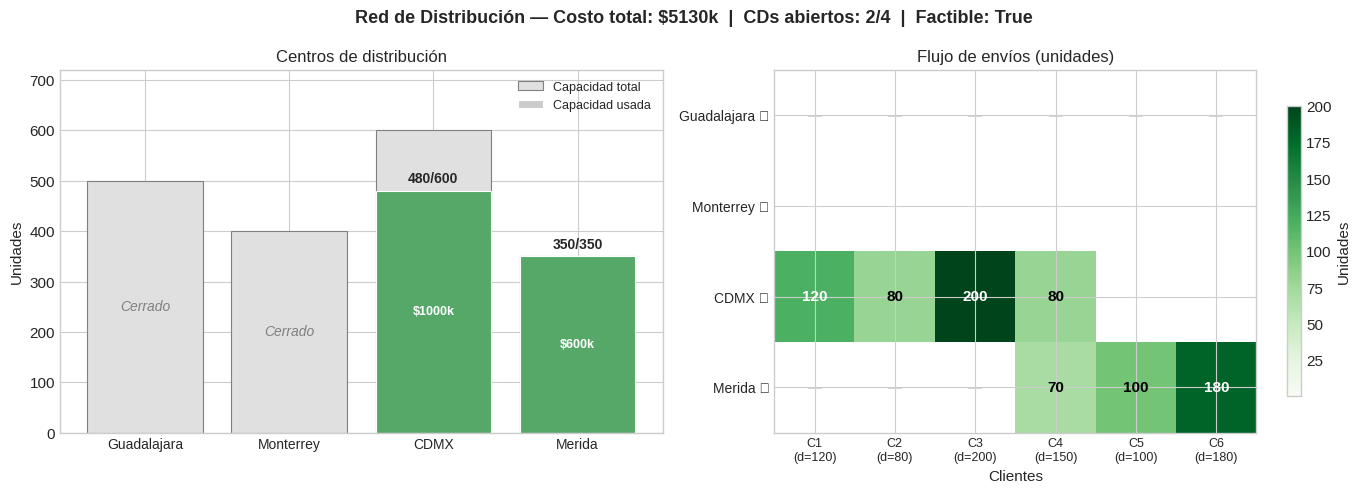

In [21]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 5 ===

def plot_p5(y_opt, X_opt, costo_opt):
    """Visualiza la red de distribucion.

    Debe mostrar:
    - Que CDs estan abiertos (con capacidad usada vs disponible)
    - Flujo de envios: de cada CD a cada cliente

    Args:
        y_opt: np.array (4,)
        X_opt: np.array (4, 6)
        costo_opt: float
    """
    # raise NotImplementedError
    info = verificar_p5(y_opt, X_opt)
    cap_usada = info['capacidad_usada']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Red de Distribución — Costo total: ${costo_opt:.0f}k  |  "
                 f"CDs abiertos: {int(y_opt.sum())}/{n_cds_p5}  |  "
                 f"Factible: {info['factible']}",
                 fontsize=13, fontweight='bold')

    # ── Panel 1: CDs abiertos con capacidad usada vs disponible ──────
    x_pos = np.arange(n_cds_p5)
    colores_cd = ['#55A868' if yi else '#CCCCCC' for yi in y_opt]

    # Barra de capacidad total (fondo)
    ax1.bar(x_pos, capacidades_p5, color='#E0E0E0', edgecolor='gray',
            linewidth=0.8, label='Capacidad total')

    # Barra de capacidad usada (encima)
    bars = ax1.bar(x_pos, cap_usada, color=colores_cd, edgecolor='white',
                   linewidth=0.8, label='Capacidad usada')

    for i, (bar, yi) in enumerate(zip(bars, y_opt)):
        if yi:
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                     f'{cap_usada[i]:.0f}/{capacidades_p5[i]}',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
                     f'${costos_fijos_p5[i]}k', ha='center', va='center',
                     fontsize=9, color='white', fontweight='bold')
        else:
            ax1.text(bar.get_x() + bar.get_width() / 2, capacidades_p5[i] / 2,
                     'Cerrado', ha='center', va='center',
                     fontsize=10, color='gray', fontstyle='italic')

    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(ciudades_p5, fontsize=10)
    ax1.set_ylabel('Unidades', fontsize=11)
    ax1.set_title('Centros de distribución', fontsize=12)
    ax1.legend(fontsize=9)
    ax1.set_ylim(0, max(capacidades_p5) * 1.2)

    # ── Panel 2: Flujo de envíos (heatmap) ───────────────────────────
    clientes_labels = [f'C{j+1}\n(d={demandas_p5[j]})' for j in range(n_clientes_p5)]

    cmap = plt.cm.Greens
    cmap.set_under('white')
    im = ax2.imshow(X_opt, cmap=cmap, aspect='auto', vmin=0.1)

    # Etiquetas en cada celda
    for i in range(n_cds_p5):
        for j in range(n_clientes_p5):
            val = X_opt[i, j]
            if val > 1e-6:
                ax2.text(j, i, f'{val:.0f}', ha='center', va='center',
                         fontsize=11, fontweight='bold', color='white' if val > 100 else 'black')
            else:
                ax2.text(j, i, '—', ha='center', va='center',
                         fontsize=10, color='lightgray')

    ax2.set_xticks(range(n_clientes_p5))
    ax2.set_xticklabels(clientes_labels, fontsize=9)
    ax2.set_yticks(range(n_cds_p5))
    estado = ['✓' if yi else '✗' for yi in y_opt]
    ax2.set_yticklabels([f'{c} {e}' for c, e in zip(ciudades_p5, estado)], fontsize=10)
    ax2.set_xlabel('Clientes', fontsize=11)
    ax2.set_title('Flujo de envíos (unidades)', fontsize=12)
    plt.colorbar(im, ax=ax2, shrink=0.8, label='Unidades')

    plt.tight_layout()
    plt.show()
    


y_opt_p5, X_opt_p5, costo_opt_p5 = resolver_p5()
info_p5 = verificar_p5(y_opt_p5, X_opt_p5)

print(f"Solucion P5:")
for i, (ciudad, abierto) in enumerate(zip(ciudades_p5, y_opt_p5)):
    if abierto > 0.5:
        cap_usada = X_opt_p5[i].sum()
        print(f"  {ciudad}: ABIERTO ({cap_usada:.0f}/{capacidades_p5[i]} unidades)")
        for j in range(n_clientes_p5):
            if X_opt_p5[i, j] > 0.1:
                print(f"    -> Cliente C{j+1}: {X_opt_p5[i, j]:.0f} unidades")
print(f"Costo total: ${costo_opt_p5:.0f}k")
print(f"Factible: {info_p5['factible']}")

plot_p5(y_opt_p5, X_opt_p5, costo_opt_p5)